# SEAS - Side Project

In [ ]:
from pathlib import Path
from collections import Counter
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display
from matplotlib.colors import LinearSegmentedColormap


In [ ]:
ROOT = Path('..') if Path('../outputs').exists() else Path('.')
OUTPUT_DIR = ROOT / 'outputs' / 'direct_prompting'
ARTIFACT_DIR = ROOT / 'paper_artifacts' / 'seas'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DIALECTS = ['PNB', 'PNN', 'PNT1', 'PNT2', 'PNT3', 'PNT4']
VARIANTS = ['standard'] + DIALECTS
TASK_ORDER = ['MCQA', 'NLI', 'QA', 'SENT']
TASK_MAP = {'mcqa': 'MCQA', 'nli': 'NLI', 'qa': 'QA', 'sentiment': 'SENT', 'sent': 'SENT'}
TASK_LABELS = {'MCQA': 'MCQA', 'NLI': 'NLI', 'QA': 'QA', 'SENT': 'Sentiment'}

EXPECTED_MODELS = [
    ('qwen_2_5_0_5b_instruct', 'Qwen2.5 0.5B'),
    ('qwen_2_5_3b_instruct', 'Qwen2.5 3B'),
    ('qwen_2_5_7b_instruct', 'Qwen2.5 7B'),
    ('llama_3_1_8b_instruct', 'Llama 3.1 8B'),
    ('mistral_7b_instruct_v0_3', 'Mistral 7B'),
    ('gemma_2_9b_it', 'Gemma 2 9B'),
    ('vistral_7b_chat', 'Vistral 7B'),
    ('seallm_7b_chat', 'SeaLLM 7B'),
    ('gpt_4o', 'GPT-4o'),
]
MODEL_ORDER = [slug for slug, _ in EXPECTED_MODELS]
MODEL_LABELS = dict(EXPECTED_MODELS)
REGION_MAP = {
    'PNB': 'Northern',
    'PNN': 'Southern',
    'PNT1': 'Central',
    'PNT2': 'Central',
    'PNT3': 'Central',
    'PNT4': 'Central',
}
REGION_ORDER = ['Northern', 'Central', 'Southern']

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def save_and_show(fig, stem: str):
    png = ARTIFACT_DIR / f'{stem}.png'
    pdf = ARTIFACT_DIR / f'{stem}.pdf'
    fig.savefig(png, bbox_inches='tight')
    fig.savefig(pdf, bbox_inches='tight')
    print(f'wrote {png}')
    print(f'wrote {pdf}')
    display(DisplayImage(filename=str(png)))
    plt.close(fig)

def save_table(table: pd.DataFrame, stem: str):
    csv = ARTIFACT_DIR / f'{stem}.csv'
    tex = ARTIFACT_DIR / f'{stem}.tex'
    table.to_csv(csv, index=False)
    table.to_latex(tex, index=False, escape=True)
    print(f'wrote {csv}')
    print(f'wrote {tex}')

def normalize_answer(value) -> str:
    if isinstance(value, list):
        value = value[0] if value else ''
    if value is None:
        return ''
    text = str(value).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\.,;:!?\(\)\[\]\{\}"\'`]+', '', text)
    return text.strip()

def exact_match(prediction, gold) -> float:
    golds = gold if isinstance(gold, list) else [gold]
    pred = normalize_answer(prediction)
    return float(any(pred == normalize_answer(g) for g in golds))

def token_f1(prediction, gold) -> float:
    if isinstance(gold, list):
        return max([token_f1(prediction, g) for g in gold] or [0.0])
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    overlap = sum((Counter(pred_tokens) & Counter(gold_tokens)).values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def as_prob_dict(value):
    return value if isinstance(value, dict) and len(value) > 0 else None

def normalized_entropy(prob_dict):
    probs = as_prob_dict(prob_dict)
    if not probs or len(probs) <= 1:
        return np.nan
    arr = np.array([float(v) for v in probs.values() if pd.notna(v) and float(v) >= 0], dtype=float)
    if arr.sum() <= 0:
        return np.nan
    arr = arr / arr.sum()
    arr = arr[arr > 0]
    return float(-(arr * np.log2(arr)).sum() / math.log2(len(probs)))

def js_divergence(p, q):
    p = as_prob_dict(p)
    q = as_prob_dict(q)
    if not p or not q:
        return np.nan
    labels = sorted(set(p) | set(q))
    p_arr = np.array([float(p.get(label, 0.0)) for label in labels], dtype=float)
    q_arr = np.array([float(q.get(label, 0.0)) for label in labels], dtype=float)
    if p_arr.sum() <= 0 or q_arr.sum() <= 0:
        return np.nan
    p_arr = p_arr / p_arr.sum()
    q_arr = q_arr / q_arr.sum()
    m_arr = 0.5 * (p_arr + q_arr)
    def kl(a, b):
        mask = a > 0
        return float((a[mask] * np.log2(a[mask] / b[mask])).sum())
    return 0.5 * kl(p_arr, m_arr) + 0.5 * kl(q_arr, m_arr)

def pct_or_dash(value, digits=1):
    return '-' if pd.isna(value) else f'{100 * value:.{digits}f}'


## Load and Pair Outputs

Rows are loaded directly from `outputs/direct_prompting/`. A dialect row is paired with its matching standard row by `(model, task, id)` before computing drops, flips, confidence changes, and distribution shift.

In [2]:
records = []
for path in sorted(OUTPUT_DIR.glob('*.jsonl')):
    model_slug = path.stem
    with path.open(encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            task = TASK_MAP.get(str(row.get('task', '')).lower(), str(row.get('task', '')).upper())
            variant = row.get('dialect_group') or row.get('variant') or 'standard'
            variant = 'standard' if str(variant).lower() == 'standard' else str(variant)
            prediction = row.get('prediction')
            gold = row.get('gold')
            if task == 'QA':
                score = token_f1(prediction, gold)
                correct = exact_match(prediction, gold)
            else:
                score = exact_match(prediction, gold)
                correct = score
            records.append({
                'model_slug': model_slug,
                'model': row.get('model_name') or MODEL_LABELS.get(model_slug, model_slug),
                'model_short': MODEL_LABELS.get(model_slug, row.get('model_name') or model_slug),
                'task': task,
                'id': str(row.get('id')),
                'variant': variant,
                'is_standard': variant == 'standard',
                'region': REGION_MAP.get(variant),
                'gold': gold,
                'prediction': prediction,
                'prediction_norm': normalize_answer(prediction),
                'score': score,
                'correct': correct,
                'confidence': row.get('confidence', np.nan),
                'gold_prob': row.get('gold_prob', np.nan),
                'label_probs': row.get('label_probs'),
                'entropy': normalized_entropy(row.get('label_probs')),
            })

df = pd.DataFrame(records)
if df.empty:
    print(f'No JSONL outputs found in {OUTPUT_DIR}')
else:
    df['model_slug'] = pd.Categorical(df['model_slug'], categories=MODEL_ORDER, ordered=True)
    df['task'] = pd.Categorical(df['task'], categories=TASK_ORDER, ordered=True)
    df['variant'] = pd.Categorical(df['variant'], categories=VARIANTS, ordered=True)
    df = df.sort_values(['model_slug', 'task', 'id', 'variant']).reset_index(drop=True)

std = (
    df[df['is_standard']]
    [['model_slug', 'task', 'id', 'score', 'correct', 'prediction_norm', 'confidence', 'gold_prob', 'label_probs', 'entropy']]
    .rename(columns={
        'score': 'standard_score',
        'correct': 'standard_correct',
        'prediction_norm': 'standard_prediction_norm',
        'confidence': 'standard_confidence',
        'gold_prob': 'standard_gold_prob',
        'label_probs': 'standard_label_probs',
        'entropy': 'standard_entropy',
    })
)
paired = df[~df['is_standard']].merge(std, on=['model_slug', 'task', 'id'], how='left')
paired['performance_drop'] = paired['standard_score'] - paired['score']
paired['harmful_flip'] = ((paired['standard_correct'] == 1.0) & (paired['correct'] == 0.0)).astype(float)
paired['beneficial_flip'] = ((paired['standard_correct'] == 0.0) & (paired['correct'] == 1.0)).astype(float)
paired['prediction_flip'] = (paired['standard_prediction_norm'] != paired['prediction_norm']).astype(float)
paired['confidence_change'] = paired['confidence'] - paired['standard_confidence']
paired['confidence_drop'] = paired['standard_confidence'] - paired['confidence']
paired['gold_prob_drop'] = paired['standard_gold_prob'] - paired['gold_prob']
paired['entropy_change'] = paired['entropy'] - paired['standard_entropy']
paired['js_divergence'] = paired.apply(lambda r: js_divergence(r.get('standard_label_probs'), r.get('label_probs')), axis=1)

coverage = df.groupby(['model_short', 'task', 'variant'], observed=True).size().reset_index(name='rows')
print(f'Loaded {len(df):,} rows from {df["model_slug"].nunique()} available models')
print(f'Paired dialect rows: {len(paired):,}')
display(coverage.head(20))


Loaded 2,442 rows from 3 available models
Paired dialect rows: 1,710


,model_short,task,variant,rows
0,Llama 3.1 8B,MCQA,standard,92
1,Llama 3.1 8B,MCQA,PNB,20
2,Llama 3.1 8B,MCQA,PNN,52
3,Llama 3.1 8B,MCQA,PNT1,40
4,Llama 3.1 8B,MCQA,PNT2,12
5,Llama 3.1 8B,MCQA,PNT3,20
6,Llama 3.1 8B,MCQA,PNT4,75
7,Llama 3.1 8B,NLI,standard,28
8,Llama 3.1 8B,NLI,PNB,12
9,Llama 3.1 8B,NLI,PNN,10


## Regional Performance with Harmful Flip Markers

Bars show performance by broad dialect region. Red `x` markers indicate harmful flip rate for the same model-region pair; larger markers mean a higher harmful flip rate.

wrote ..\paper_artifacts\seas\seas_table_region_performance.csv
wrote ..\paper_artifacts\seas\seas_table_region_performance.tex


region,Model,Northern,Central,Southern
0,Qwen2.5 0.5B,-,-,-
1,Qwen2.5 3B,34.6,32.0,48.8
2,Qwen2.5 7B,-,-,-
3,Llama 3.1 8B,43.0,31.2,45.4
4,Mistral 7B,48.9,29.0,35.4
5,Gemma 2 9B,-,-,-
6,Vistral 7B,-,-,-
7,SeaLLM 7B,-,-,-
8,GPT-4o,-,-,-


wrote ..\paper_artifacts\seas\seas_figure_region_performance_harmful_flip.png
wrote ..\paper_artifacts\seas\seas_figure_region_performance_harmful_flip.pdf


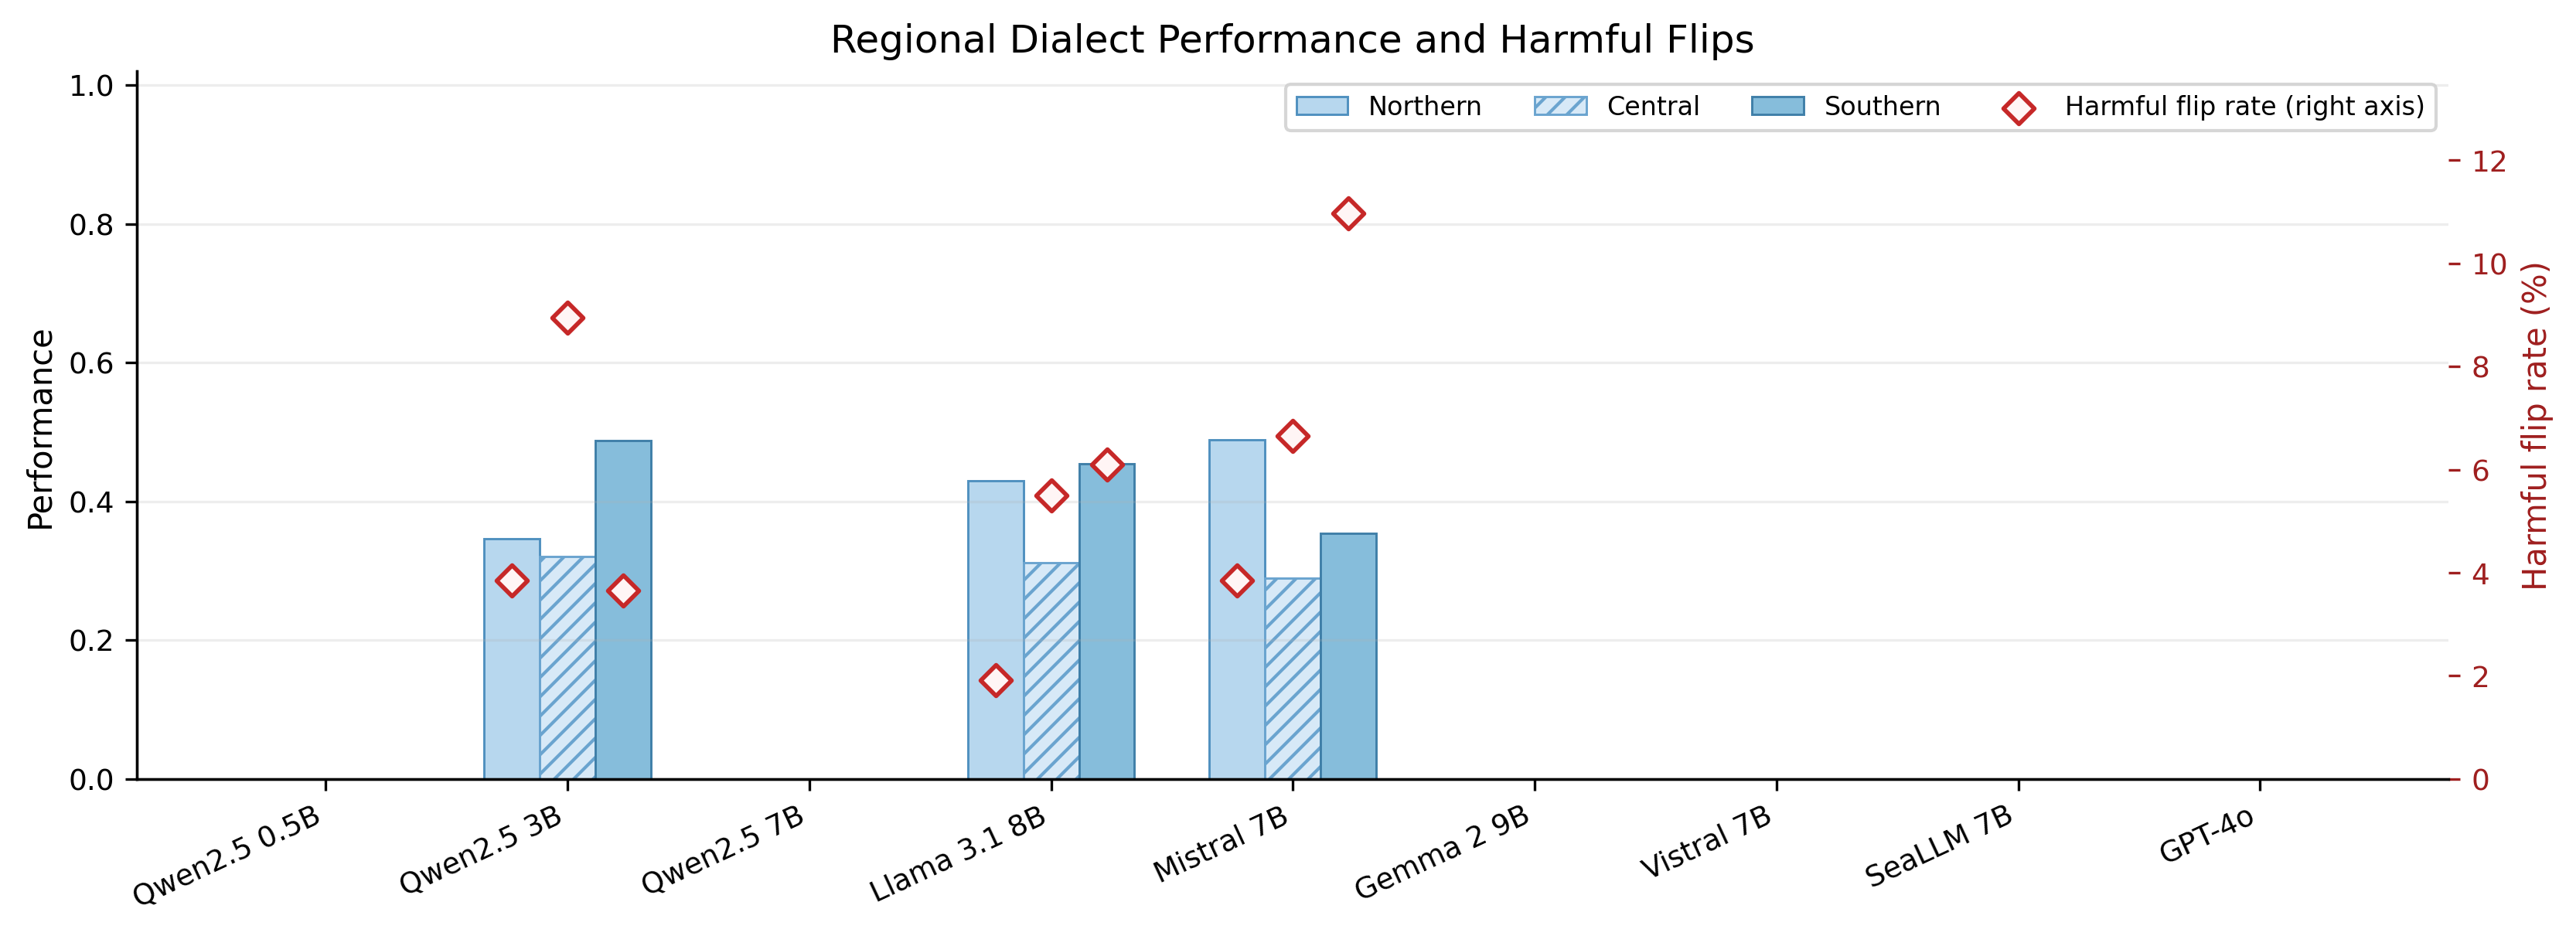

In [ ]:
if paired.empty:
    region_perf = pd.DataFrame(index=MODEL_ORDER, columns=REGION_ORDER)
    region_flip = pd.DataFrame(index=MODEL_ORDER, columns=REGION_ORDER)
else:
    region_stats = (
        paired.groupby(['model_slug', 'region'], observed=True)
        .agg(
            performance=('score', 'mean'),
            paired_standard=('standard_score', 'mean'),
            drop=('performance_drop', 'mean'),
            harmful_flip=('harmful_flip', 'mean'),
            n=('id', 'size'),
        )
        .reset_index()
    )
    region_perf = region_stats.pivot(index='model_slug', columns='region', values='performance').reindex(index=MODEL_ORDER, columns=REGION_ORDER)
    region_flip = region_stats.pivot(index='model_slug', columns='region', values='harmful_flip').reindex(index=MODEL_ORDER, columns=REGION_ORDER)

table = region_perf.reset_index()
table['Model'] = table['model_slug'].map(MODEL_LABELS)
table = table[['Model'] + REGION_ORDER]
formatted = table.copy()
for col in REGION_ORDER:
    formatted[col] = formatted[col].map(pct_or_dash)
save_table(formatted, 'seas_table_region_performance')
display(formatted)

x = np.arange(len(MODEL_ORDER))
width = 0.23
fig, ax = plt.subplots(figsize=(11.2, 4.15))
ax2 = ax.twinx()
specs = [
    ('Northern', x - width, '#b7d7ee', '#4f90bf', None),
    ('Central', x, '#d7e9f7', '#6aa4cf', '////'),
    ('Southern', x + width, '#86bddb', '#3f7fa8', None),
]
max_flip_pp = 0.0
for region, xpos, color, edge, hatch in specs:
    values = region_perf[region].fillna(0.0).to_numpy(dtype=float)
    ax.bar(xpos, values, width=width, color=color, edgecolor=edge, linewidth=0.7, hatch=hatch, label=region)
    flips = region_flip[region].to_numpy(dtype=float)
    flip_pp = flips * 100
    valid = pd.notna(flip_pp)
    if np.any(valid):
        max_flip_pp = max(max_flip_pp, float(np.nanmax(flip_pp[valid])))
        ax2.scatter(xpos[valid], flip_pp[valid], marker='D', s=46, facecolors='#fff5f5', edgecolors='#c62828', linewidths=1.35, zorder=5)

ax.set_ylim(0, 1.02)
ax.set_ylabel('Performance')
ax2.set_ylim(0, max(5.0, max_flip_pp * 1.25))
ax2.set_ylabel('Harmful flip rate (%)', color='#9f1f1f')
ax2.tick_params(axis='y', colors='#9f1f1f')
ax.set_xticks(x, [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=25, ha='right')
ax.set_title('Regional Dialect Performance and Harmful Flips')
ax.grid(axis='y', alpha=0.22)
handles, labels = ax.get_legend_handles_labels()
flip_handle = ax2.scatter([], [], marker='D', s=46, facecolors='#fff5f5', edgecolors='#c62828', linewidths=1.35, label='Harmful flip rate')
ax.legend(handles + [flip_handle], labels + ['Harmful flip rate'], loc='upper right', ncol=4, frameon=True)
fig.tight_layout()
save_and_show(fig, 'seas_figure_region_performance_harmful_flip')


## Model-by-Dialect Performance Drop

This heatmap keeps the six dialect groups separate. Values are paired performance drops in percentage points, computed as standard score minus dialect score.

wrote ..\paper_artifacts\seas\seas_figure_model_dialect_drop_heatmap.png
wrote ..\paper_artifacts\seas\seas_figure_model_dialect_drop_heatmap.pdf


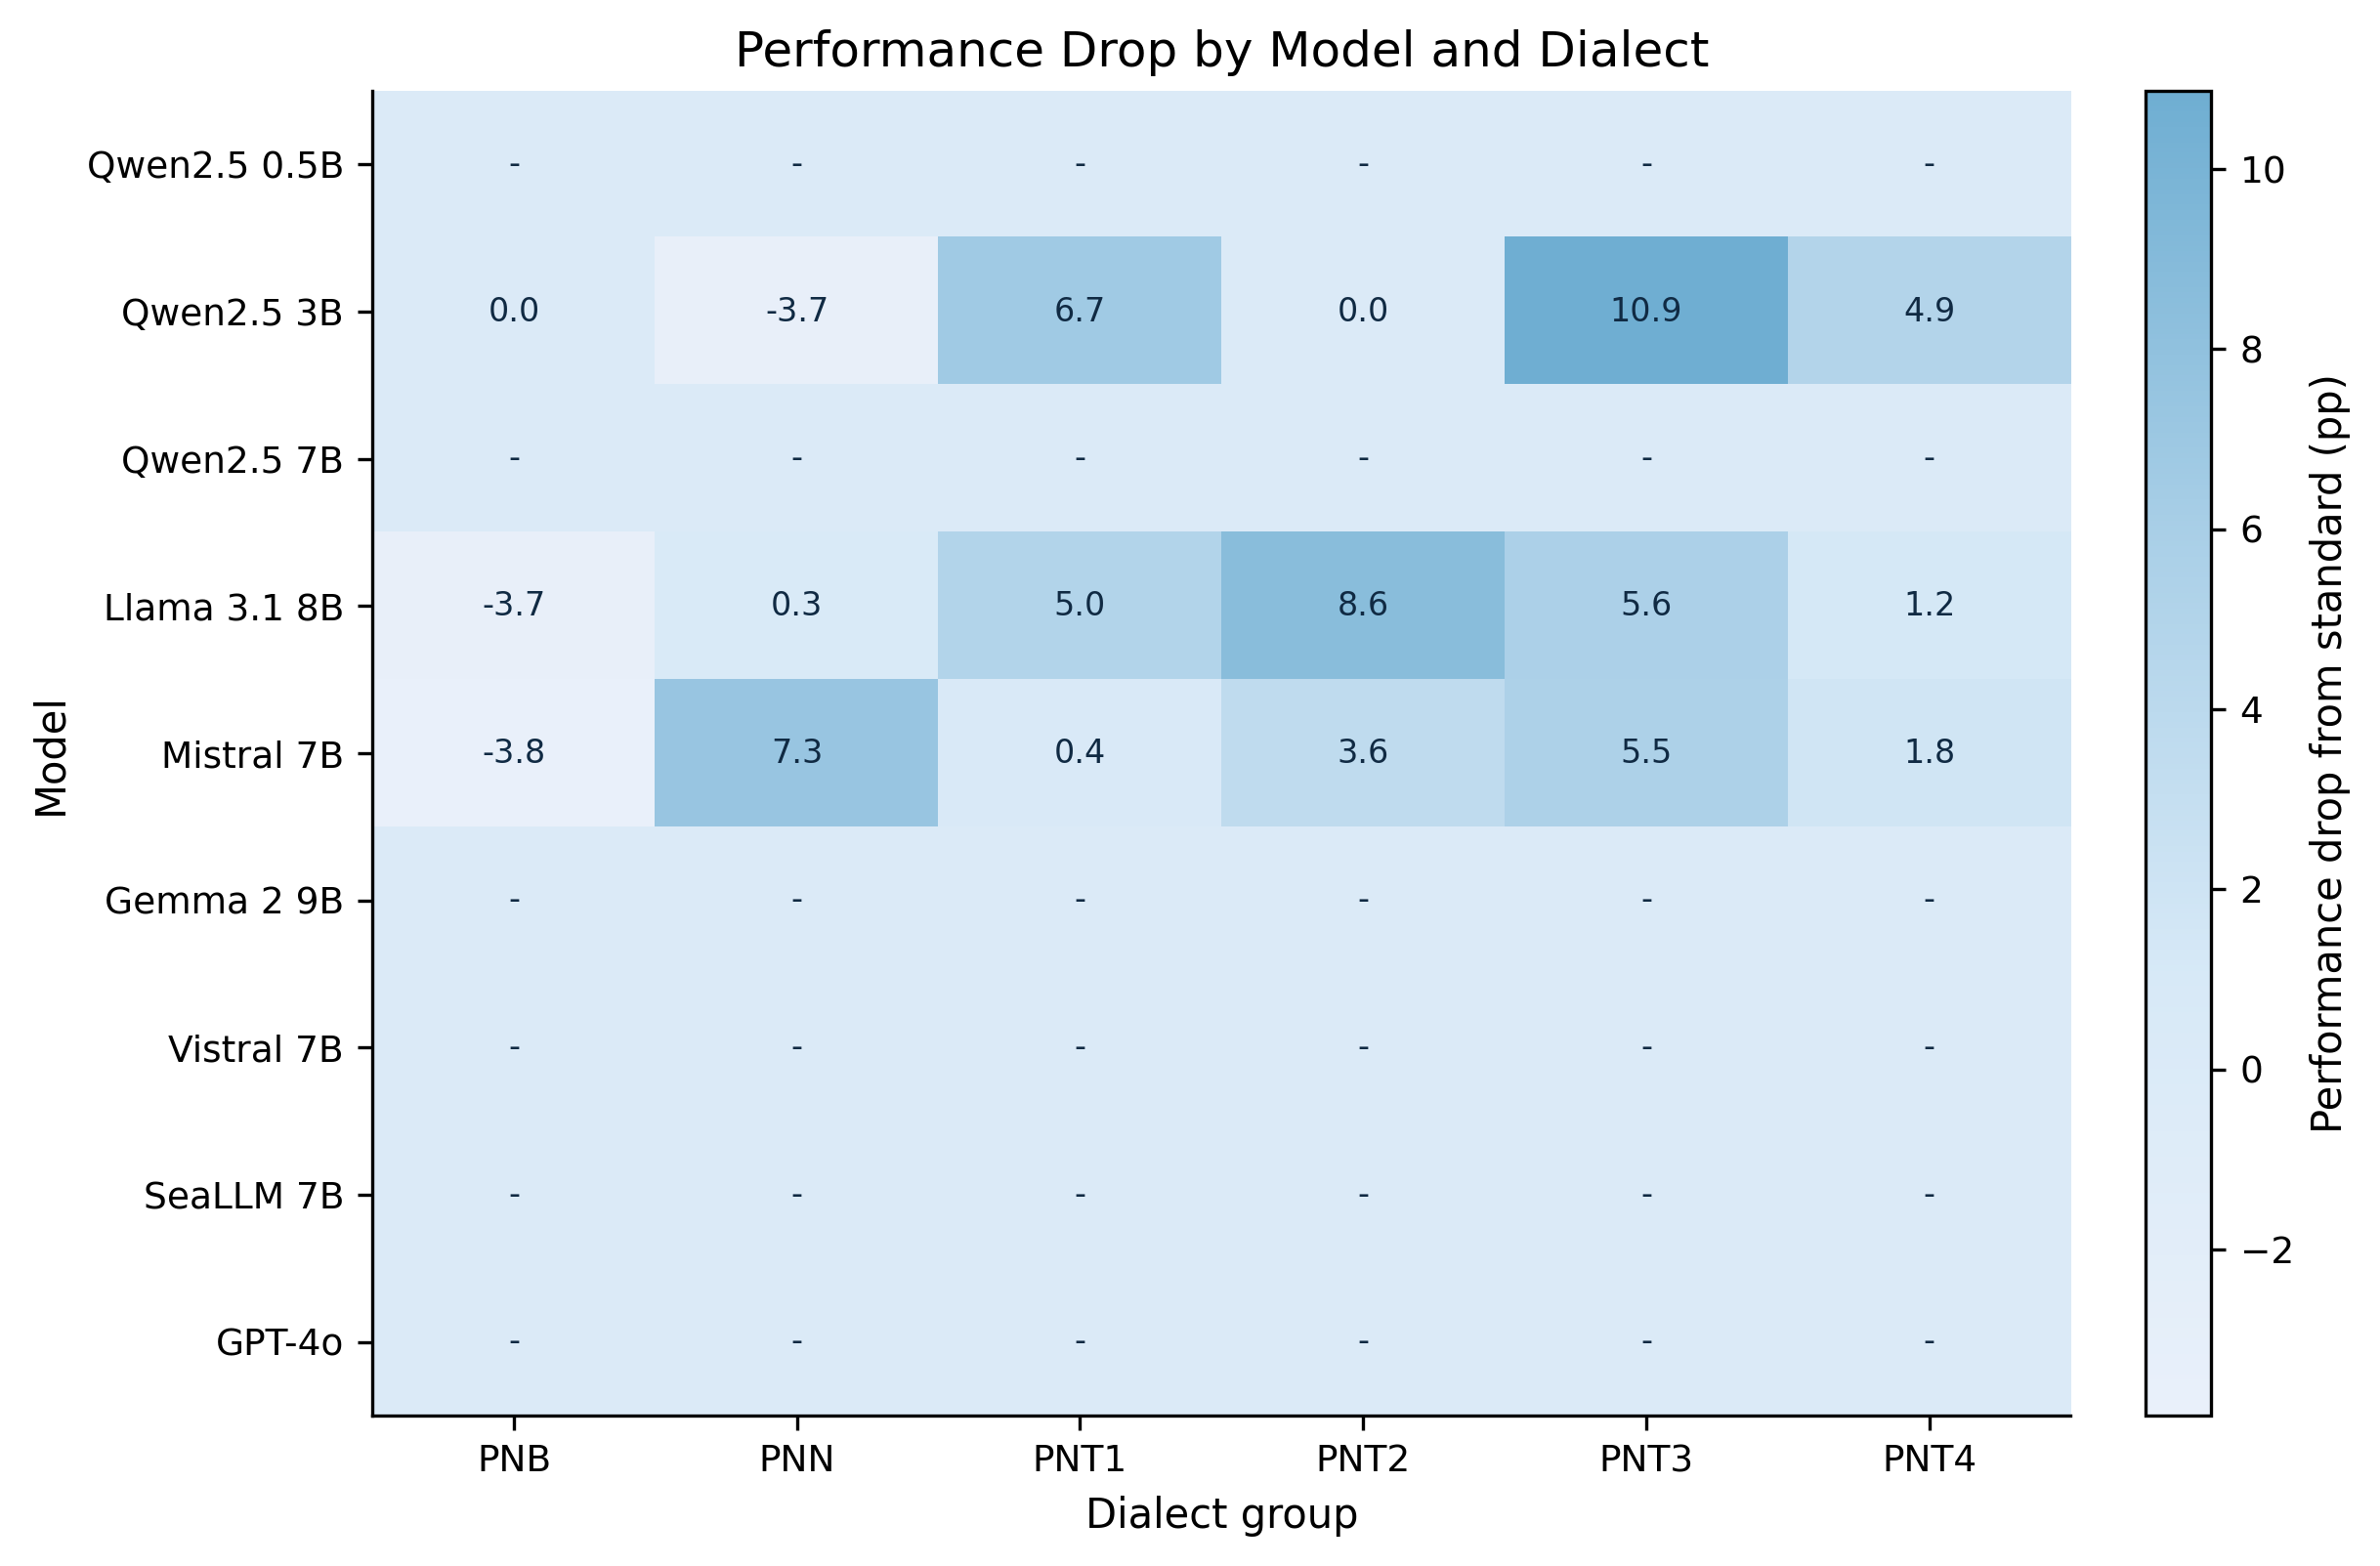

In [4]:
if paired.empty:
    drop_matrix = pd.DataFrame(index=MODEL_ORDER, columns=DIALECTS)
else:
    drop_matrix = (
        paired.groupby(['model_slug', 'variant'], observed=True)['performance_drop']
        .mean()
        .unstack('variant')
        .reindex(index=MODEL_ORDER, columns=DIALECTS)
        * 100
    )

pastel_blues = LinearSegmentedColormap.from_list('pastel_blues', ["#e9f0fa", '#d7e9f7', '#a9cfe7', '#6faed2'])
plot_vals = drop_matrix.fillna(0.0)
vmax = max(1.0, float(np.nanmax(plot_vals.values)) if plot_vals.size else 1.0)
vmin = min(0.0, float(np.nanmin(plot_vals.values)) if plot_vals.size else 0.0)

fig, ax = plt.subplots(figsize=(8.2, 5.45))
im = ax.imshow(plot_vals.values, cmap=pastel_blues, vmin=vmin, vmax=vmax, aspect='auto')
ax.set_title('Performance Drop by Model and Dialect')
ax.set_xlabel('Dialect group')
ax.set_ylabel('Model')
ax.set_xticks(np.arange(len(DIALECTS)), DIALECTS)
ax.set_yticks(np.arange(len(MODEL_ORDER)), [MODEL_LABELS[m] for m in MODEL_ORDER])
for i, model in enumerate(MODEL_ORDER):
    for j, dialect in enumerate(DIALECTS):
        val = drop_matrix.loc[model, dialect]
        ax.text(j, i, '-' if pd.isna(val) else f'{val:.1f}', ha='center', va='center', fontsize=8, color='#102a43')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Performance drop from standard (pp)')
fig.tight_layout()
save_and_show(fig, 'seas_figure_model_dialect_drop_heatmap')


## Normalization
Continue...

In [2]:
# RUN PRIVATE HF NORMALIZER: tarudesu/mbart-large-50

import os
import pandas as pd
import torch
from transformers import AutoConfig, AutoTokenizer, AutoModelForSeq2SeqLM, GenerationConfig

PRIVATE_NORMALIZER_ID = "tarudesu/mbart-large-50"
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
        if HF_TOKEN:
            os.environ["HF_TOKEN"] = HF_TOKEN
    except Exception:
        pass

if not HF_TOKEN:
    raise ValueError("HF_TOKEN is not set. Add it to the environment or Colab Secrets first.")

cache_kwargs = {}
if "CACHE_DIR" in globals():
    cache_kwargs["cache_dir"] = CACHE_DIR

private_tokenizer = AutoTokenizer.from_pretrained(
    PRIVATE_NORMALIZER_ID,
    token=HF_TOKEN,
    **cache_kwargs,
)

# Some local transformers versions reject older MBART configs whose
# generation field has early_stopping=None. Colab may silently accept it.
private_config = AutoConfig.from_pretrained(
    PRIVATE_NORMALIZER_ID,
    token=HF_TOKEN,
    **cache_kwargs,
)
if getattr(private_config, "early_stopping", None) is None:
    private_config.early_stopping = False

private_model = AutoModelForSeq2SeqLM.from_pretrained(
    PRIVATE_NORMALIZER_ID,
    token=HF_TOKEN,
    config=private_config,
    **cache_kwargs,
)
private_model.generation_config = GenerationConfig.from_model_config(private_model.config)
if getattr(private_model.generation_config, "early_stopping", None) is None:
    private_model.generation_config.early_stopping = False

private_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
private_model = private_model.to(private_device)
private_model.eval()

if hasattr(private_tokenizer, "src_lang"):
    private_tokenizer.src_lang = "vi_VN"
if hasattr(private_tokenizer, "tgt_lang"):
    private_tokenizer.tgt_lang = "vi_VN"

print(f"Loaded {PRIVATE_NORMALIZER_ID} on {private_device}")


def normalize_private(texts, max_length=80, batch_size=8, num_beams=1):
    single_input = isinstance(texts, str)
    if single_input:
        texts = [texts]

    predictions = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = private_tokenizer(
            batch,
            return_tensors="pt",
            max_length=max_length,
            truncation=True,
            padding=True,
        )
        inputs.pop("token_type_ids", None)
        inputs = {key: value.to(private_device) for key, value in inputs.items()}

        generate_kwargs = {
            "max_length": max_length,
            "do_sample": False,
            "num_beams": num_beams,
            "pad_token_id": private_tokenizer.pad_token_id,
            "eos_token_id": private_tokenizer.eos_token_id,
            "early_stopping": False,
        }
        lang_code_to_id = getattr(private_tokenizer, "lang_code_to_id", None)
        if isinstance(lang_code_to_id, dict) and "vi_VN" in lang_code_to_id:
            generate_kwargs["forced_bos_token_id"] = lang_code_to_id["vi_VN"]

        with torch.inference_mode():
            output_ids = private_model.generate(**inputs, **generate_kwargs)

        predictions.extend(private_tokenizer.batch_decode(output_ids, skip_special_tokens=True))

    return predictions[0] if single_input else predictions


manual_examples = [
    "Mi đi mô rứa?",
    "Tau hổng biết chuyện ni.",
    "Bữa ni trời nóng quá, tui muốn đi uống cà phê.",
    "Mạ nói con về nhà ăn cơm nghe chưa?",
    "Cái ni mắc quá, bớt chút được hông?",
    "Hoàng Phụng Thế nghe tin Sư Ôn về đã mằn gì?"
]

manual_df = pd.DataFrame({"dialect": manual_examples})
manual_df["normalized"] = normalize_private(manual_df["dialect"].tolist())
display(manual_df)

# Optional quick reference check on the public ViDia2Std test split.
# Increase n only after the manual examples look sane.
n = 20
quick_test_df = pd.read_csv("https://huggingface.co/datasets/Biu3010/ViDia2Std/resolve/main/test.csv").dropna().head(n)
quick_test_df["prediction"] = normalize_private(quick_test_df["dialect"].tolist(), batch_size=8)
quick_test_df["exact_match"] = (
    quick_test_df["prediction"].str.strip().str.lower()
    == quick_test_df["standard"].str.strip().str.lower()
)
print(f"Quick exact match on first {n} ViDia2Std test rows: {quick_test_df['exact_match'].mean():.3f}")
display(quick_test_df[["dialect", "prediction", "standard", "exact_match"]])

c:\Users\ad\miniconda3\envs\humanoid_world_model\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\ad\miniconda3\envs\humanoid_world_model\lib\site-packages\transformers\generation\configuration_utils.py:554: UserWarning: `num_beams` is set to None - defaulting to 1.
  warnings.warn("`num_beams` is set to None - defaulting to 1.", UserWarning)


Loaded tarudesu/mbart-large-50 on cpu


,dialect,normalized
0,Mi đi mô rứa?,Mày đi đâu vậy?
1,Tau hổng biết chuyện ni.,Tao không biết chuyện này.
2,"Bữa ni trời nóng quá, tui muốn đi uống cà phê.","Bữa nay trời nóng quá, tôi muốn đi uống cà phê."
3,Mạ nói con về nhà ăn cơm nghe chưa?,Mẹ nói con về nhà ăn cơm nhé.
4,"Cái ni mắc quá, bớt chút được hông?","Cái này đắt quá, bớt chút được không?"
5,Hoàng Phụng Thế nghe tin Sư Ôn về đã mằn gì?,Hoàng Phụng Thế nghe tin Sư Ôn về đã làm gì?


c:\Users\ad\miniconda3\envs\humanoid_world_model\lib\site-packages\transformers\generation\configuration_utils.py:554: UserWarning: `num_beams` is set to None - defaulting to 1.
  warnings.warn("`num_beams` is set to None - defaulting to 1.", UserWarning)


Quick exact match on first 20 ViDia2Std test rows: 0.250


,dialect,prediction,standard,exact_match
0,thuốc xịn bơ không có lợi nhuận.,thuốc xịn thì không có lợi nhuận,thuốc xịn thì không có lợi nhuận.,False
1,"Trông nớ ngập mau, tội chưa nả.","Trông đó ngập mau, tội chưa.","Trông đó ngập mau, tội chưa.",True
2,Ngủ thì có biết chi mô mà.,Ngủ thì có biết gì đâu mà.,Ngủ thì có biết gì đâu mà.,True
3,Táo toàn quả to giòn ngọt. Để mình túi nựa với...,Táo toàn quả to giòn ngọt. Để mình túi nữa với...,Táo toàn quả to giòn ngọt. Để mình một túi nữa...,False
4,"Nguyễn Trúc chịu khó, đảm đang thì có chứ hiền...","Nguyễn Trúc chịu khó, đảm đang thì có chứ hiền...","Nguyễn Trúc chịu khó, đảm đang thì có chứ hiền...",False
5,"Lên chợ phường 5 đi, không thua chi chợ Đông H...","Lên chợ phường 5 đi, không thua gì chợ Đông Hà...","Lên chợ phường 5 đi, không thua gì chợ Đông Hà...",False
6,"Hồi nớ bằng tuổi hắn, tui cũng không khổ như r...","Hồi đó bằng tuổi nó, tôi cũng không khổ như th...","Hồi đấy bằng tuổi nó, tôi cũng không khổ như t...",False
7,May cho tiệm tóc nớ nữa chơ không thì cũng toa...,May cho tiệm tóc đó nữa chứ không thì cũng toa...,May cho tiệm tóc đó nữa chứ không thì cũng toa...,False
8,"tợn hi, công nhận miềng lái xe siêu thiệt","quyết liệt nhỉ, công nhận mình lái xe siêu thật","sợ nhỉ, công nhận mình lái xe siêu thiệt.",False
9,"2 con chưa mần được, nói chi 3 con.","2 con chưa làm được, nói gì 3 con","2 con chưa làm được, nói gì 3 con.",False


In [4]:
manual_examples = [
    "Sau ni, phần đông mấy người có điểm thi TOEIC lên đến 600, 700 sẽ là nữ.",
    "Sau khi hủy kết hôn với người nỏ có trình độ học vấn thì ả nớ lấy dông khác",
    "Ban đầu, tại ren Cô-li-a lại bất ngờ khi nghe mẹ kêu đi giặt quần áo?",
    "moá, thật chư bọn ni nuôi mần chi rứa hè?"
]
manual_df = pd.DataFrame({"dialect": manual_examples})
manual_df["normalized"] = normalize_private(manual_df["dialect"].tolist())
display(manual_df)


c:\Users\ad\miniconda3\envs\humanoid_world_model\lib\site-packages\transformers\generation\configuration_utils.py:554: UserWarning: `num_beams` is set to None - defaulting to 1.
  warnings.warn("`num_beams` is set to None - defaulting to 1.", UserWarning)


,dialect,normalized
0,"Sau ni, phần đông mấy người có điểm thi TOEIC ...","Sau này, phần đông mấy người có điểm thi TOEIC..."
1,Sau khi hủy kết hôn với người nỏ có trình độ h...,Sau khi hủy kết hôn với người không có trình đ...
2,"Ban đầu, tại ren Cô-li-a lại bất ngờ khi nghe ...",Ban đầu tại sao Cô-li-a lại bất ngờ khi nghe m...
3,"moá, thật chư bọn ni nuôi mần chi rứa hè?","Mẹ, thật chứ bọn này nuôi làm gì vậy nhỉ?"
